# Heart Attack Prediction

## Предобработка данных

In [5]:
# чтение данных из файла
!pip install kaggle

In [6]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: rename kaggle.json to /Users/natalia/.kaggle/kaggle.json: No such file or directory
chmod: /Users/natalia/.kaggle/kaggle.json: No such file or directory


In [7]:
!kaggle competitions download -c tech-weekend-data-science-hackathon

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!unzip tech-weekend-data-science-hackathon.zip

In [9]:
!ls

SF_mod_2_mnist_2_.ipynb
asset-v1_SkillFactory+MFTIDS+SEP2023+type@asset+block@SF_mod_3_skillfactory_dl_3_screencast_v2.ipynb
asset-v1_SkillFactory+MFTIDS+SEP2023+type@asset+block@mnist_intro.ipynb
dl_mod_4_3__1_.ipynb
final_task.ipynb
sample_submission.csv
tech-weekend-data-science-hackathon.zip
test.csv
train.csv
transfer_learning_keras_flowers_sf_dl_v3.ipynb
~$ заболевания итого проект.docx
Добро_пожаловать_в_Colab!.ipynb
сс заболевания итого проект.docx


In [10]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import sklearn
import torch

In [12]:
data = pd.read_csv('train.csv')
data.head()

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [18]:
data.shape

(600000, 15)

In [13]:
data.columns

Index(['ID', 'age', 'sex', 'chest', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'maximum_heart_rate_achieved',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'number_of_major_vessels', 'thal', 'class'],
      dtype='str')

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  slope      

Нет пропусков и значения все числовые (float64 и int64). Однако есть категориальные признаки, закодированные числовыми значениями.

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,600000.0,299999.500000,173205.225094,0.000000,149999.750000,299999.500000,449999.250000,599999.000000
age,600000.0,54.426085,9.086041,26.061695,48.078493,55.133425,60.663775,79.591647
sex,600000.0,0.677447,0.467454,0.000000,0.000000,1.000000,1.000000,1.000000
chest,600000.0,3.170247,0.949618,-0.538498,3.000000,3.000000,4.000000,4.000000
resting_blood_pressure,600000.0,131.340485,17.842450,82.918527,119.924094,129.727941,139.915216,209.673650
serum_cholestoral,600000.0,249.592420,51.699976,98.326263,216.475964,244.233699,274.345453,527.755764
fasting_blood_sugar,600000.0,0.150757,0.357812,0.000000,0.000000,0.000000,0.000000,1.000000
resting_electrocardiographic_results,600000.0,1.020148,0.994204,0.000000,0.000000,2.000000,2.000000,2.000000
maximum_heart_rate_achieved,600000.0,149.592069,23.072593,61.844168,135.704237,153.224828,165.165497,208.735196
exercise_induced_angina,600000.0,0.333502,0.471464,0.000000,0.000000,0.000000,1.000000,1.000000


В столбце chest (загрудинная боль) есть отрицательные значения
Oldpeak (депрессия ST-сегмента)  есть отрицательные значения

In [16]:
data.nunique()

ID                                      600000
age                                     594106
sex                                          2
chest                                   133009
resting_blood_pressure                  596241
serum_cholestoral                       598797
fasting_blood_sugar                          2
resting_electrocardiographic_results         3
maximum_heart_rate_achieved             597583
exercise_induced_angina                      2
oldpeak                                 384255
slope                                        3
number_of_major_vessels                      4
thal                                         3
class                                        2
dtype: int64

категориальные: sex, chest, fasting_blood_sugar, resting_electrocardiographic_results, exercise_induced_angina, slope, number_of_major_vessels, thal

числовые: age, resting_blood_pressure, serum_cholestoral, maximum_heart_rate_achieved, oldpeak

И согласно статье, категориальными признаками в задаче считаются sex, cp, fbs, restecg, exang, slope, ca, thal

Для Logistic Regression - необходимо кодировать категориальные признаки.  

In [33]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

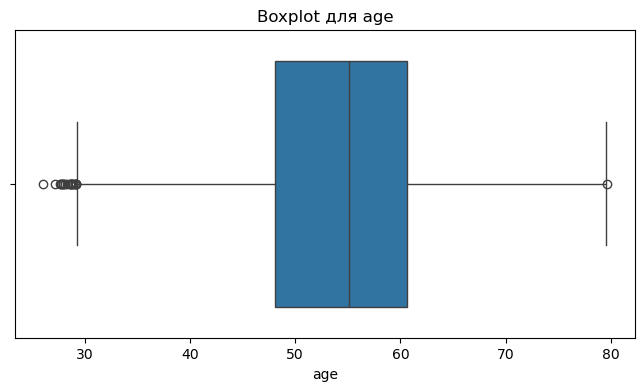

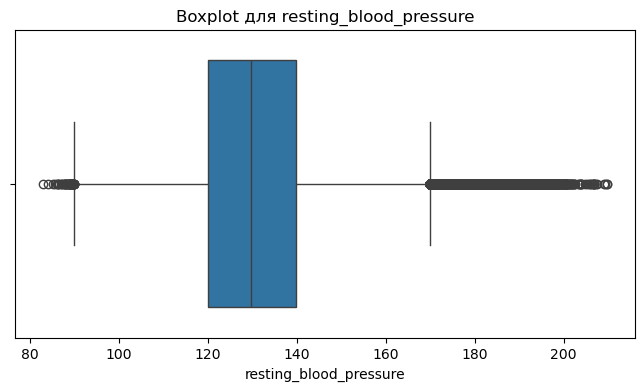

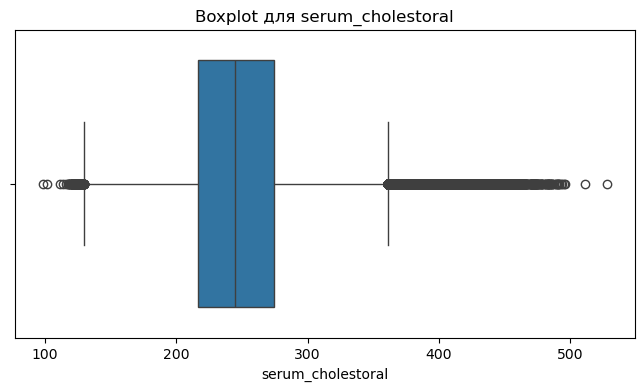

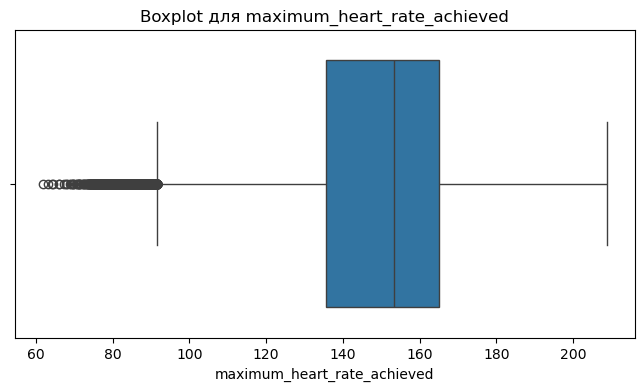

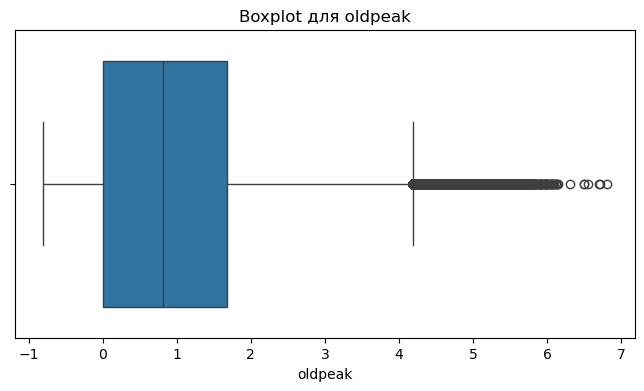

In [21]:
# Визуализируем распределение числовых признаков с помощью boxplot
num_cols = [
    "age",
    "resting_blood_pressure",
    "serum_cholestoral",
    "maximum_heart_rate_achieved",
    "oldpeak"
]

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot для {col}")
    plt.show()

oldpeak это депрессия ST-сегмента

In [18]:
# Проверим количество отрицательных значений в oldpeak
negative_oldpeak_count = (data["oldpeak"] < 0).sum()
print("Количество отрицательных значений oldpeak:", negative_oldpeak_count)

Количество отрицательных значений oldpeak: 2365


In [19]:
negative_oldpeak_share = (data["oldpeak"] < 0).mean() * 100

print("Количество отрицательных значений oldpeak:", negative_oldpeak_count)
print(f"Доля отрицательных значений oldpeak: {negative_oldpeak_share:.3f}%")

Количество отрицательных значений oldpeak: 2365
Доля отрицательных значений oldpeak: 0.394%


Не будем его удалять, он может быть отрицательным 

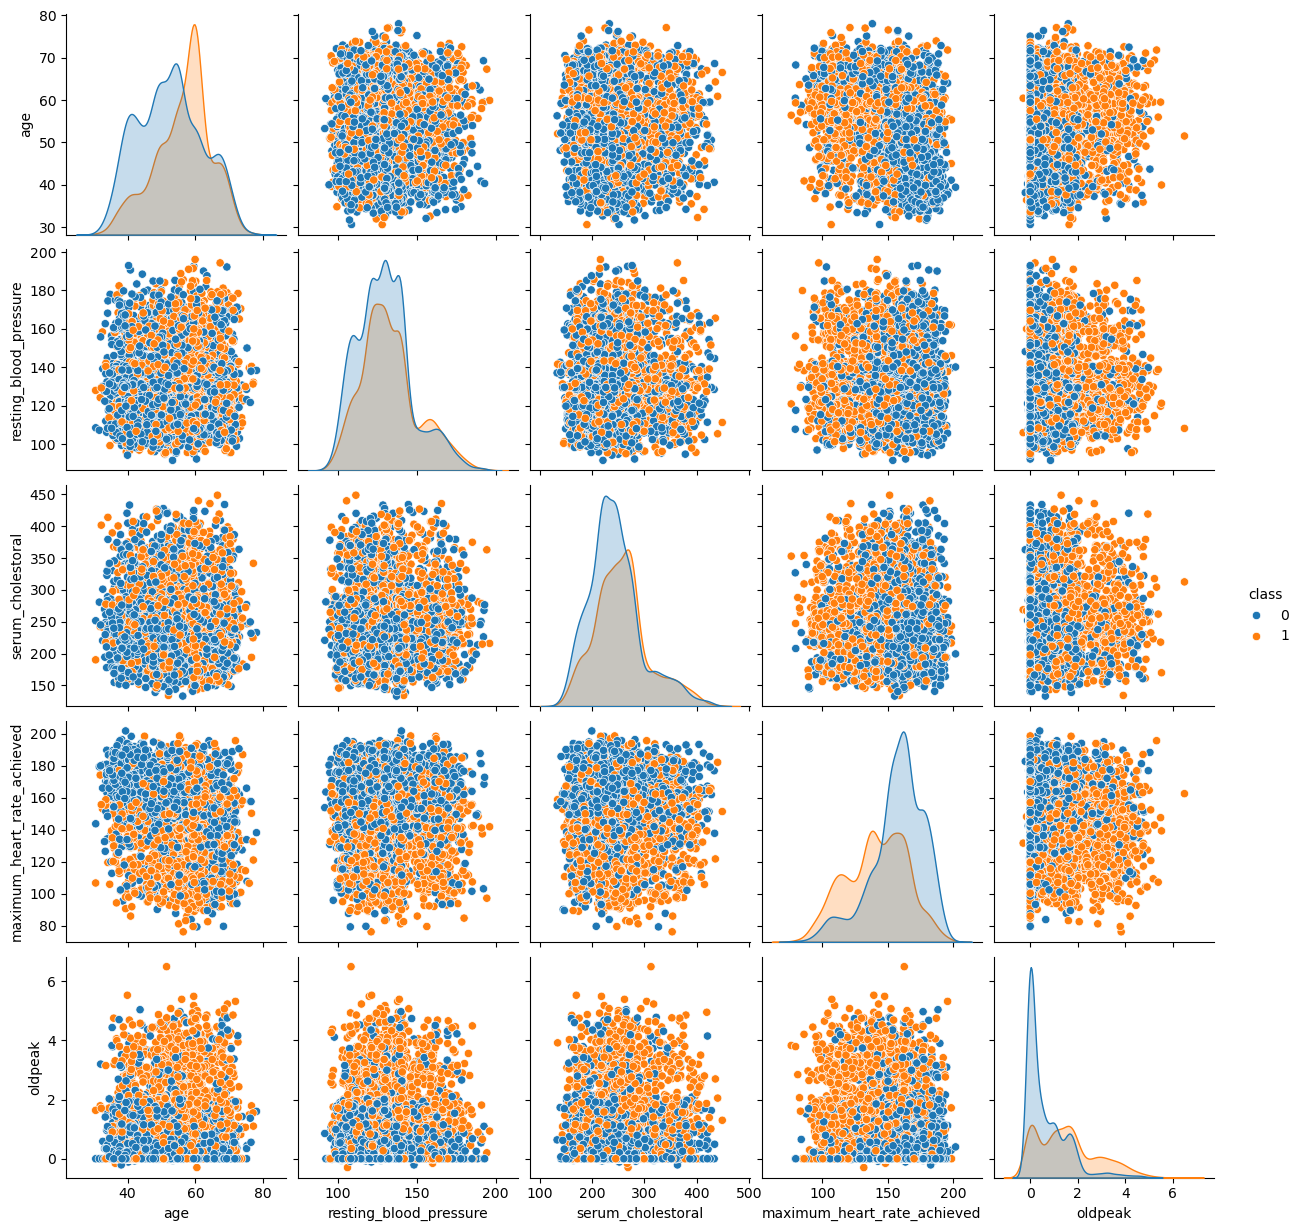

In [22]:
# Возьмем небольшую выборку для визуализации pairplot, чтобы не перегружать график

sample_data = data.sample(n=5000, random_state=42)

sns.pairplot(sample_data[num_cols + ["class"]], hue="class")
plt.show()

По матрице диаграмм рассеяния видно, что классы 0 и 1 в значительной степени пересекаются, поэтому явного линейного разделения между ними не наблюдается.

<Figure size 1200x800 with 0 Axes>

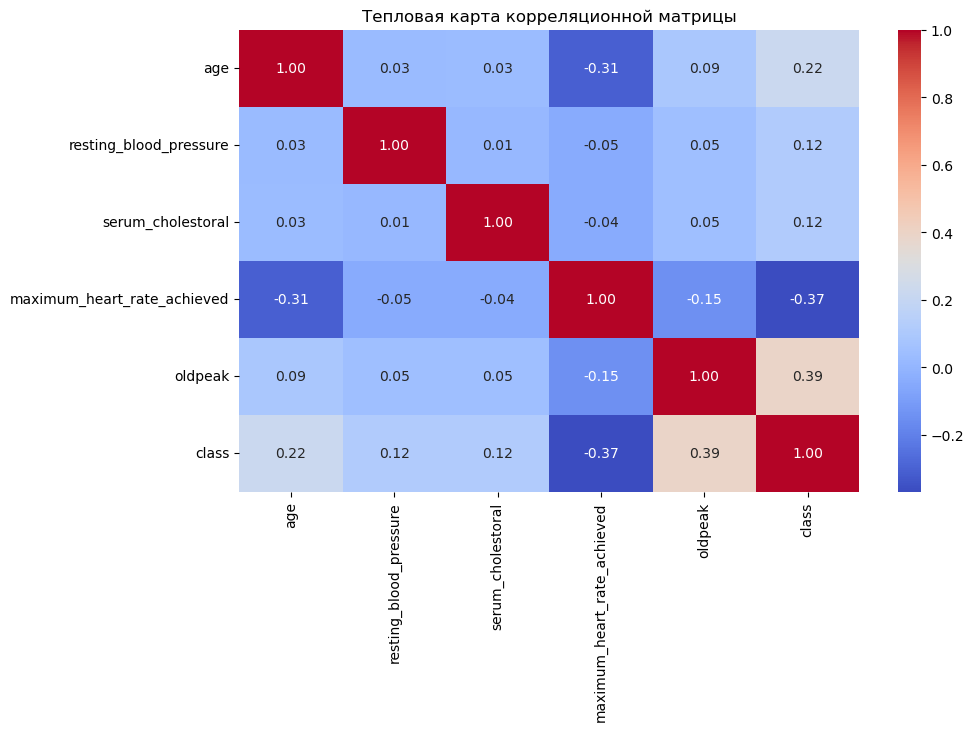

In [27]:
# Построим тепловую карту корреляционной матрицы для числовых признаков
plt.figure(figsize=(12, 8))
plt.figure(figsize=(10, 6))
corr_matrix = data[num_cols + ["class"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Тепловая карта корреляционной матрицы")
plt.show()

По тепловой карте корреляционной матрицы видно, что наибольшую связь с целевой переменной class имеют признаки oldpeak (0.39) и maximum_heart_rate_achieved (-0.37). Признак age также демонстрирует слабую положительную корреляцию с целевой переменной (0.22). Для признаков resting_blood_pressure и serum_cholestoral связь с целевой переменной выражена слабо. Между числовыми признаками сильной корреляции не наблюдается, что говорит об отсутствии выраженной мультиколлинеарности.


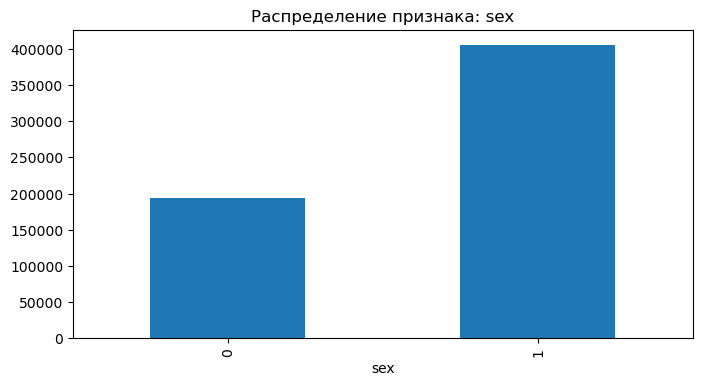

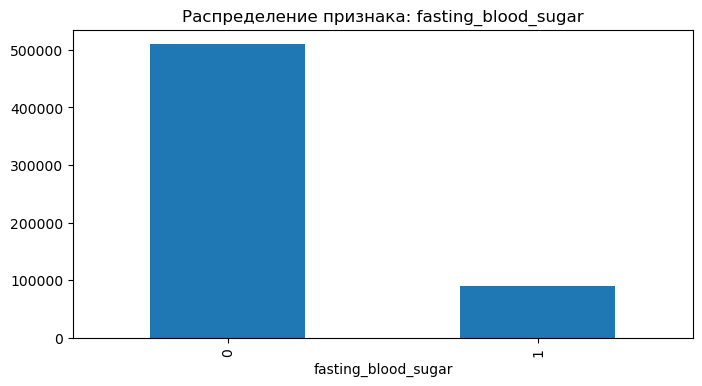

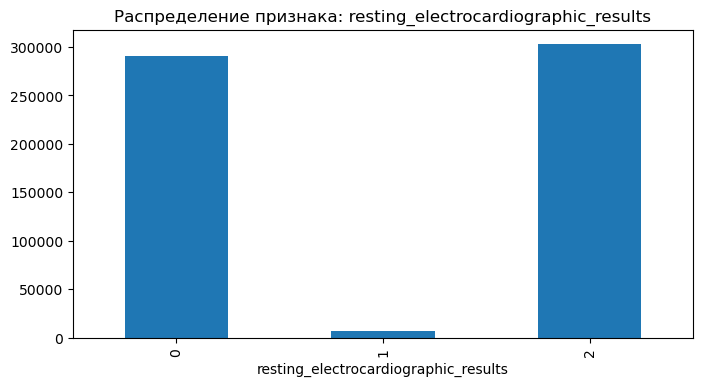

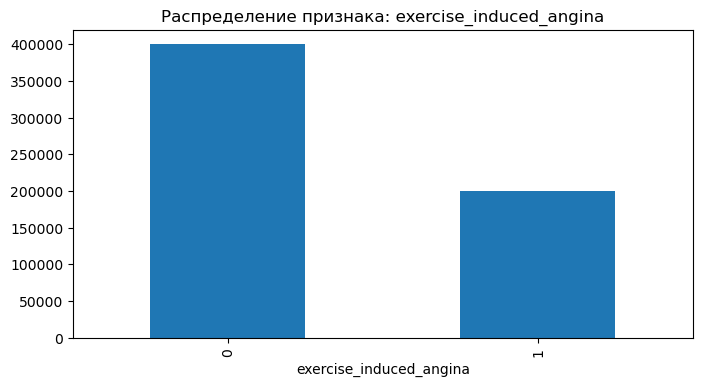

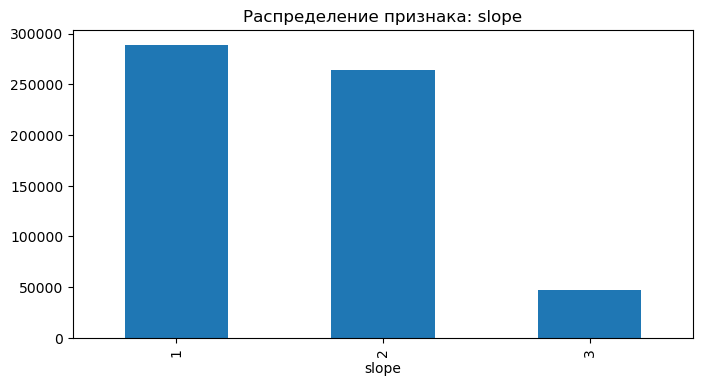

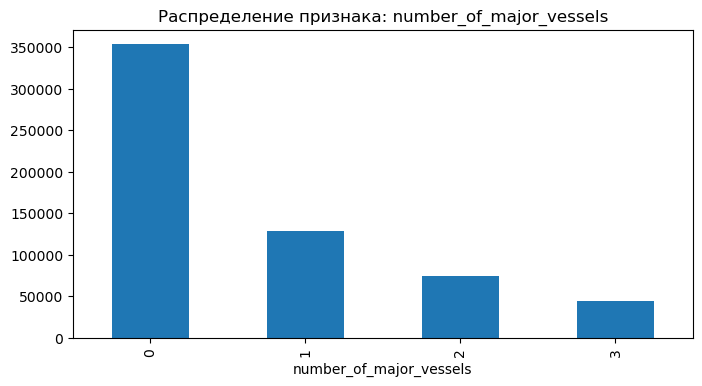

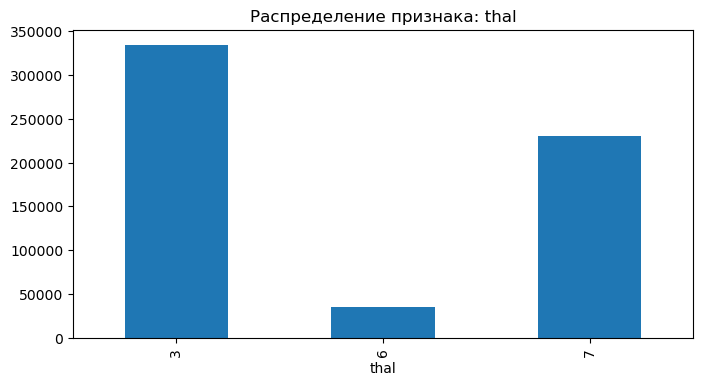

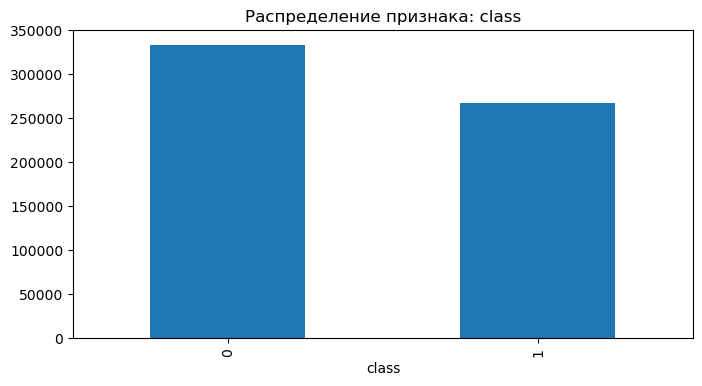

In [63]:
# Визуализируем категориальные признаки, за исключением сhest

cat_cols = [
    "sex",
    "fasting_blood_sugar",
    "resting_electrocardiographic_results",
    "exercise_induced_angina",
    "slope",
    "number_of_major_vessels",
    "thal",
    "class"
]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    data[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Распределение признака: {col}")
    plt.show()

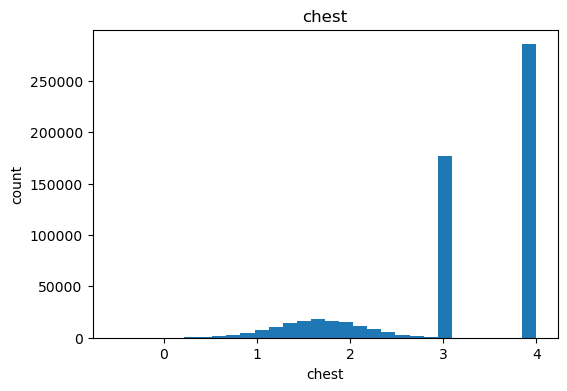

In [62]:
# Визуализируем распределение переменной chest
plt.figure(figsize=(6, 4))
plt.hist(data["chest"], bins=30)
plt.title("chest")
plt.xlabel("chest")
plt.ylabel("count")
plt.show()

Согласно статье, признак chest относится к категориальным. Однако в используемом датасете он представлен большим количеством дробных значений, поэтому в рамках данной работы он рассматривался как числовой признак

In [28]:
# Подготовка данных для модели - тренировочная выборка
X = data.drop(columns=["class", "ID"])
y = data["class"]

cat_cols = [
    "sex",
    "fasting_blood_sugar",
    "resting_electrocardiographic_results",
    "exercise_induced_angina",
    "slope",
    "number_of_major_vessels",
    "thal"
]
# Преобразуем категориальные признаки в числовые с помощью one-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

In [30]:
# загрузка тестовой выборки
test = pd.read_csv('test.csv')

In [ ]:
# Подготовка данных для модели - тестовая выборка, чтобы они совпали с обучающей выборкой

X_test = test.drop(columns=["ID"])
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)
X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [34]:
# Разделим данные на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Масштабируем числовые признаки с помощью StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [36]:
# Обучим модель логистической регрессии и оценим ее качество на валидационной выборке

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_reg_pred = log_reg.predict(X_valid_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_valid, log_reg_pred))
print(classification_report(y_valid, log_reg_pred))

Logistic Regression
Accuracy: 0.8844333333333333
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     66698
           1       0.88      0.86      0.87     53302

    accuracy                           0.88    120000
   macro avg       0.88      0.88      0.88    120000
weighted avg       0.88      0.88      0.88    120000



In [37]:
# Обучим модель случайного леса и оценим ее качество на валидационной выборке

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)

print("Random Forest")
print("Accuracy:", accuracy_score(y_valid, rf_pred))
print(classification_report(y_valid, rf_pred))

Random Forest
Accuracy: 0.8946583333333333
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     66698
           1       0.89      0.87      0.88     53302

    accuracy                           0.89    120000
   macro avg       0.89      0.89      0.89    120000
weighted avg       0.89      0.89      0.89    120000



In [ ]:
# импортируем необходимые библиотеки для нейронной сети
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Подготовим данные для обучения нейронной сети - преобразуем их в тензоры и создадим DataLoaderы

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False)

In [40]:
# Определим архитектуру нейронной сети
class HeartNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HeartNet(X_train.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
# Обучим модель нейронной сети и оценим ее качество на валидационной выборке

num_epochs = 20

train_losses = []
valid_losses = []
train_accs = []
valid_accs = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    model.eval()
    epoch_valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            epoch_valid_loss += loss.item()

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            valid_correct += (preds == yb).sum().item()
            valid_total += yb.size(0)

    train_losses.append(epoch_train_loss / len(train_loader))
    valid_losses.append(epoch_valid_loss / len(valid_loader))
    train_accs.append(train_correct / train_total)
    valid_accs.append(valid_correct / valid_total)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_losses[-1]:.4f} | valid_loss={valid_losses[-1]:.4f} | "
        f"train_acc={train_accs[-1]:.4f} | valid_acc={valid_accs[-1]:.4f}"
    )

Epoch 1/20 | train_loss=0.2749 | valid_loss=0.2561 | train_acc=0.8880 | valid_acc=0.8946
Epoch 2/20 | train_loss=0.2600 | valid_loss=0.2542 | train_acc=0.8934 | valid_acc=0.8955
Epoch 3/20 | train_loss=0.2576 | valid_loss=0.2519 | train_acc=0.8944 | valid_acc=0.8964
Epoch 4/20 | train_loss=0.2555 | valid_loss=0.2508 | train_acc=0.8951 | valid_acc=0.8969
Epoch 5/20 | train_loss=0.2538 | valid_loss=0.2511 | train_acc=0.8956 | valid_acc=0.8978
Epoch 6/20 | train_loss=0.2531 | valid_loss=0.2538 | train_acc=0.8965 | valid_acc=0.8970
Epoch 7/20 | train_loss=0.2521 | valid_loss=0.2515 | train_acc=0.8965 | valid_acc=0.8971
Epoch 8/20 | train_loss=0.2515 | valid_loss=0.2520 | train_acc=0.8968 | valid_acc=0.8972
Epoch 9/20 | train_loss=0.2510 | valid_loss=0.2491 | train_acc=0.8970 | valid_acc=0.8981
Epoch 10/20 | train_loss=0.2505 | valid_loss=0.2495 | train_acc=0.8972 | valid_acc=0.8980
Epoch 11/20 | train_loss=0.2502 | valid_loss=0.2492 | train_acc=0.8973 | valid_acc=0.8981
Epoch 12/20 | train

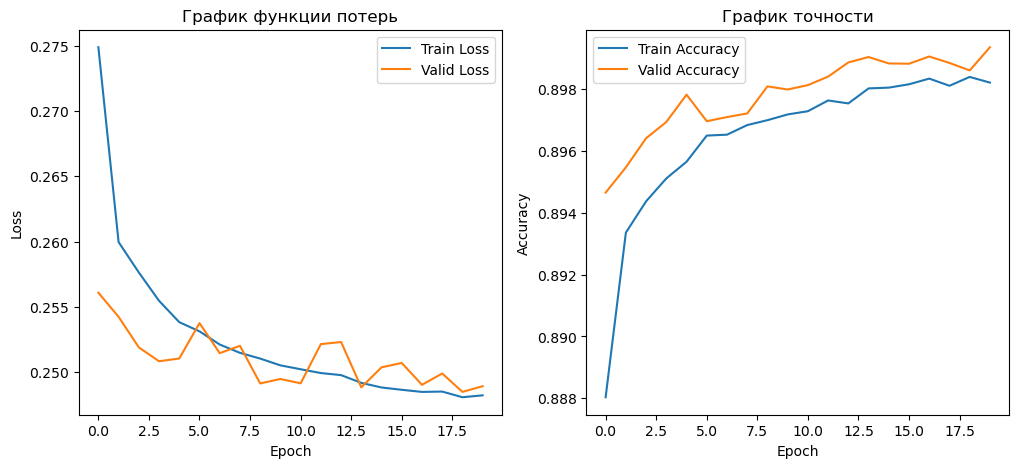

In [42]:
# графики функции потерь и точности для нейронной сети

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.title("График функции потерь")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(valid_accs, label="Valid Accuracy")
plt.title("График точности")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [43]:
# оценим качество модели нейронной сети на валидационной выборке

model.eval()
with torch.no_grad():
    valid_logits = model(X_valid_tensor.to(device))
    valid_probs = torch.sigmoid(valid_logits)
    nn_pred = (valid_probs >= 0.5).cpu().numpy().astype(int).ravel()

print("Neural Network")
print("Accuracy:", accuracy_score(y_valid, nn_pred))
print(classification_report(y_valid, nn_pred))

Neural Network
Accuracy: 0.89935
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     66698
           1       0.90      0.87      0.88     53302

    accuracy                           0.90    120000
   macro avg       0.90      0.90      0.90    120000
weighted avg       0.90      0.90      0.90    120000



In [44]:
# Сравним качество всех трех моделей на валидационной выборке

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_valid, log_reg_pred),
        accuracy_score(y_valid, rf_pred),
        accuracy_score(y_valid, nn_pred)
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
2,Neural Network,0.899350
1,Random Forest,0.894658
0,Logistic Regression,0.884433


In [45]:
# Сохраним все три модели и scaler для дальнейшего использования на тестовой выборке
import joblib

joblib.dump(log_reg, "log_reg.pkl")
joblib.dump(rf, "random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

torch.save(model.state_dict(), "heart_net.pth")

In [46]:
# скрипт для предсказания на тестовой выборке и сохранения submission.csv

class HeartNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

test = pd.read_csv("test.csv")
ids = test["ID"].copy()

X_test = test.drop(columns=["ID"])
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

feature_columns = joblib.load("feature_columns.pkl")
X_test = X_test.reindex(columns=feature_columns, fill_value=0)

scaler = joblib.load("scaler.pkl")
X_test_scaled = scaler.transform(X_test)

model = HeartNet(X_test.shape[1])
model.load_state_dict(torch.load("heart_net.pth", map_location="cpu"))
model.eval()

X_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

with torch.no_grad():
    logits = model(X_tensor)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).int().numpy().ravel()

submission = pd.DataFrame({
    "ID": ids,
    "class": preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved")

submission.csv saved


In [52]:
submission = pd.read_csv("submission.csv")
submission.head()

,ID,class
0,600000,1
1,600001,1
2,600002,0
3,600003,0
4,600004,0
